📁 Trovati 8 file CSV

   ✓ BTC m15.csv............................. -> BTC..... (648 righe, 21 colonne)
   ✓ ES m15.csv.............................. -> ES...... (1,322 righe, 21 colonne)
   ✓ FDAX m15.csv............................ -> FDAX.... (1,140 righe, 21 colonne)
   ✓ FESX m15.csv............................ -> FESX.... (479 righe, 21 colonne)
   ✓ GC m5.csv............................... -> GC...... (952 righe, 21 colonne)
   ✓ NG m15.csv.............................. -> NG...... (857 righe, 21 colonne)
   ✓ NQ m15.csv.............................. -> NQ...... (824 righe, 21 colonne)
   ✓ performance_per_ticker.csv.............. -> PERFORMANCE_PER_TICKER (7 righe, 9 colonne)

📊 Dataset totale: 6,229 righe
🔧 Colonne totali: 29
🎯 Ticker: ['BTC', 'ES', 'FDAX', 'FESX', 'GC', 'NG', 'NQ', 'PERFORMANCE_PER_TICKER']

🔍 Colonne disponibili:
   1. Trade number
   2. Instrument
   3. Account
   4. Strategy
   5. Market pos.
   6. Qty
   7. Entry price
   8. Exit price
   9. Entry time
  

C:\Users\roman\AppData\Local\Temp\ipykernel_7444\2543177293.py:142: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Period'] = pd.to_datetime(df[date_col], errors='coerce')


✅ Colonna date: 'Entry time'

🧹 Righe valide: 2,778 (rimosse 3,451)

🎯 VERIFICA DATI PER TICKER

BTC:
  Righe: 264
  Total Profit: €1,066,922.12
  Avg Trade: €4041.37
  Min Trade: €9.08
  Max Trade: €24984.08

ES:
  Righe: 432
  Total Profit: €565,221.24
  Avg Trade: €1308.38
  Min Trade: €14.32
  Max Trade: €1494.32

FDAX:
  Righe: 572
  Total Profit: €1,261,042.56
  Avg Trade: €2204.62
  Min Trade: €19.48
  Max Trade: €6244.48

FESX:
  Righe: 268
  Total Profit: €68,096.96
  Avg Trade: €254.09
  Min Trade: €6.22
  Max Trade: €1816.22

GC:
  Righe: 495
  Total Profit: €476,240.60
  Avg Trade: €962.10
  Min Trade: €3.88
  Max Trade: €6993.88

NG:
  Righe: 391
  Total Profit: €128,597.08
  Avg Trade: €328.89
  Min Trade: €3.88
  Max Trade: €493.88

NQ:
  Righe: 356
  Total Profit: €573,400.00
  Avg Trade: €1610.67
  Min Trade: €0.00
  Max Trade: €2000.00

📈 OVERALL PERFORMANCE

📊 METRICHE OVERALL:
Total Trades.................. 2,778
Total Profit.................. €4,139,520.56
Avg Trad

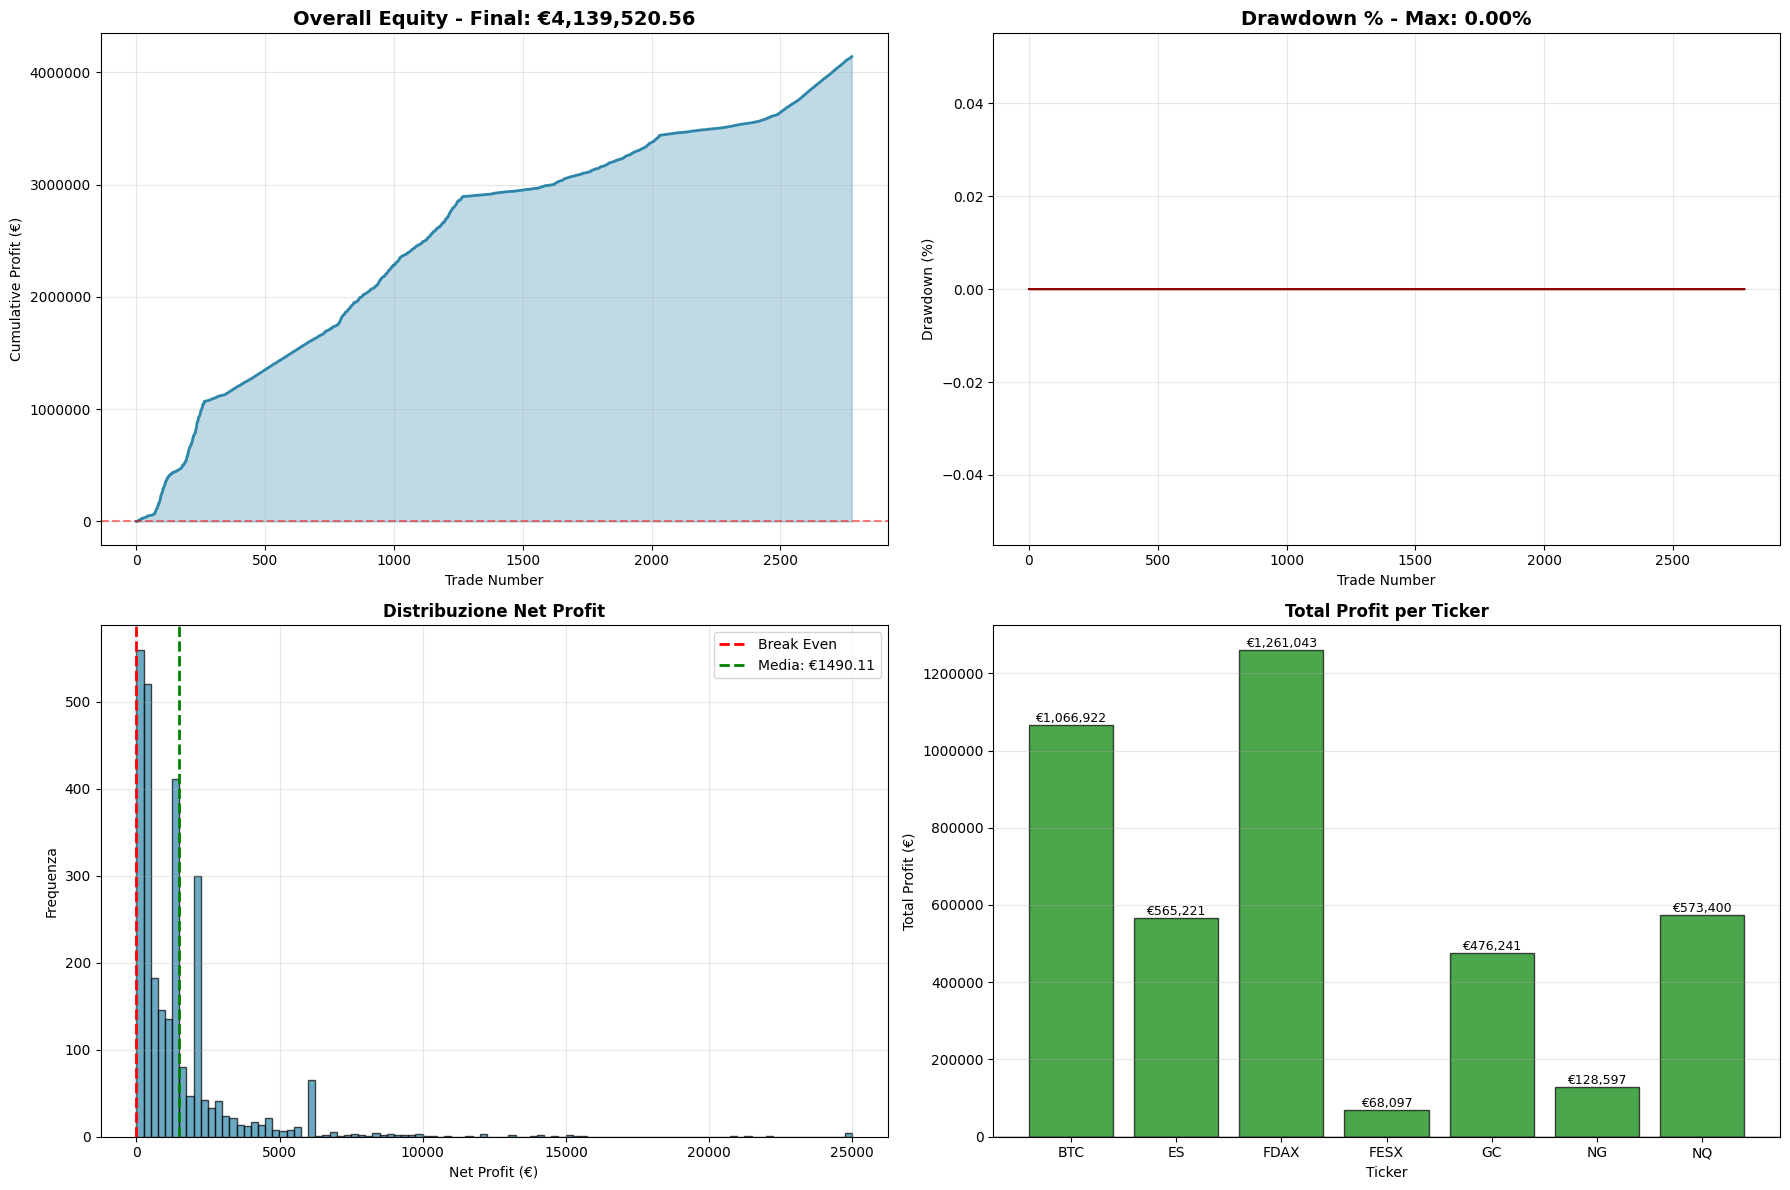

   ✓ Salvato: overall_performance.png


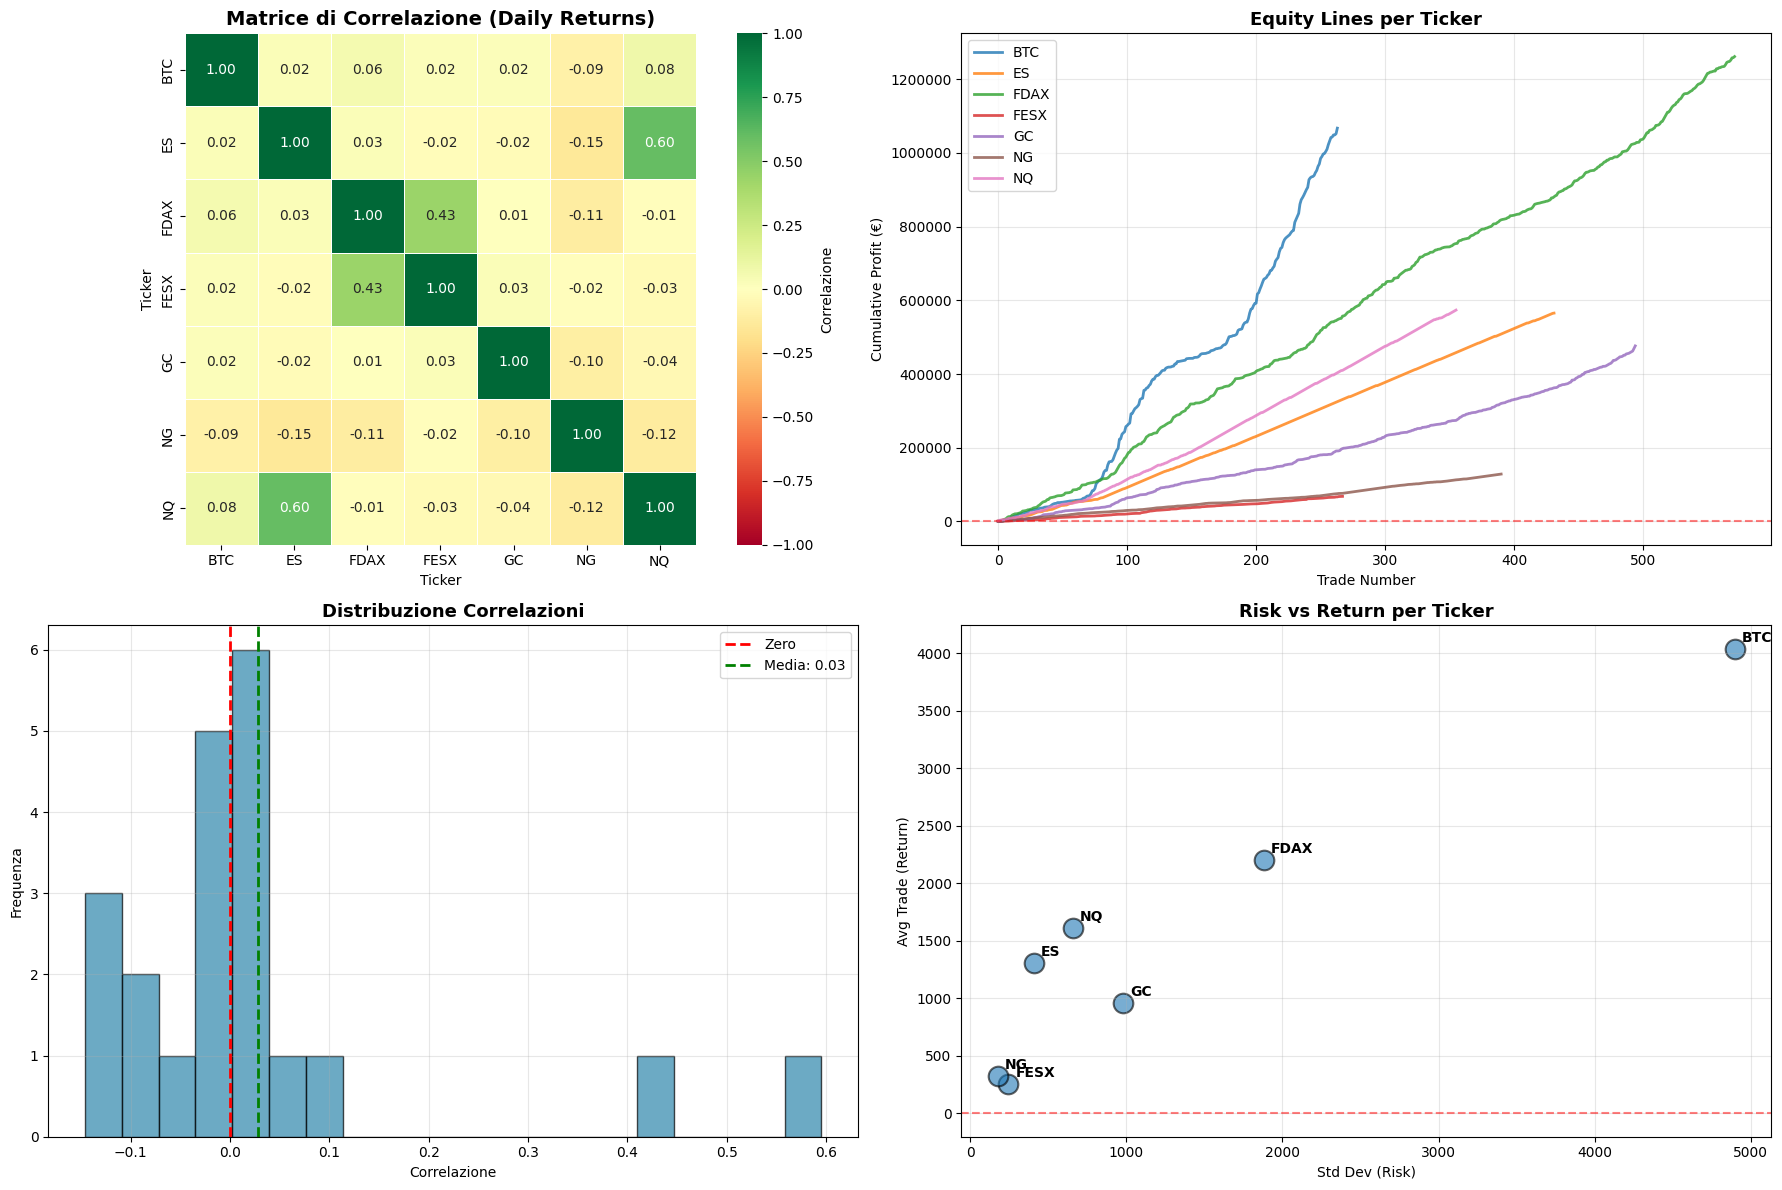

   ✓ Salvato: correlation_analysis.png

💾 Esportazione risultati...

✅ File salvati:
   - overall_metrics.csv
   - overall_performance.png
   - correlation_matrix.csv
   - performance_per_ticker.csv
   - correlation_analysis.png
   - correlation_pairs.csv

🎉 ANALISI COMPLETA!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# ========================================
# 0. CARICAMENTO CSV CON PARSING CORRETTO
# ========================================

path = r'C:\Users\roman\Desktop\quant\FVG csv\*.csv'
all_files = glob.glob(path)

print(f"📁 Trovati {len(all_files)} file CSV\n")

def estrai_ticker_da_filename(filepath):
    filename = os.path.basename(filepath).replace('.csv', '')
    if ' ' in filename:
        ticker = filename.split()[0].upper()
    else:
        ticker = filename.upper()
    return ticker

# Carica tutti i CSV con parsing corretto
dfs = []
ticker_count = {}

for file in all_files:
    try:
        # Prova prima a leggere normalmente
        temp_df = pd.read_csv(file)
        
        # Se tutte le colonne sono in una sola, prova altri separatori
        if len(temp_df.columns) == 2 or ',' in temp_df.columns[0]:
            # Prova con tab
            try:
                temp_df = pd.read_csv(file, sep='\t')
            except:
                pass
            
            # Se ancora non funziona, prova engine python con virgola
            if len(temp_df.columns) <= 2:
                try:
                    temp_df = pd.read_csv(file, sep=',', engine='python')
                except:
                    pass
        
        ticker = estrai_ticker_da_filename(file)
        temp_df['Ticker'] = ticker
        ticker_count[ticker] = ticker_count.get(ticker, 0) + 1
        dfs.append(temp_df)
        
        print(f"   ✓ {os.path.basename(file)[:40]:.<40} -> {ticker:.<8} ({len(temp_df):,} righe, {len(temp_df.columns)} colonne)")
        
    except Exception as e:
        print(f"   ✗ Errore: {os.path.basename(file)}: {e}")

if not dfs:
    print("\n❌ ERRORE: Nessun file caricato!")
    exit()

df = pd.concat(dfs, ignore_index=True)

print(f"\n📊 Dataset totale: {len(df):,} righe")
print(f"🔧 Colonne totali: {len(df.columns)}")
print(f"🎯 Ticker: {list(ticker_count.keys())}")

# ========================================
# 1. PULISCI E IDENTIFICA COLONNE
# ========================================

print("\n🔍 Colonne disponibili:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

# Funzione di pulizia migliorata
def pulisci_numeri(series):
    """Pulisce numeri con formato europeo (1.234,56) o americano (1,234.56)"""
    if series.dtype == 'object':
        # Rimuovi simboli
        cleaned = series.astype(str).str.replace('€', '').str.replace('$', '').str.replace(' ', '')
        
        # Conta punti e virgole per capire il formato
        sample = cleaned.head(100)
        has_comma = sample.str.contains(',').any()
        has_dot = sample.str.contains(r'\.').any()
        
        if has_comma and has_dot:
            # Formato tipo 1.234,56 (europeo) - rimuovi punti, converti virgola
            cleaned = cleaned.str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        elif has_comma:
            # Solo virgola - probabilmente decimale europeo
            cleaned = cleaned.str.replace(',', '.', regex=False)
        # Se solo punto, lascia così (formato americano)
        
        return pd.to_numeric(cleaned, errors='coerce')
    return pd.to_numeric(series, errors='coerce')

# Trova colonna Profit (NON Cum. net profit!)
profit_col = None
for col_name in ['Profit', 'profit', 'P&L', 'PnL', 'P/L']:
    if col_name in df.columns:
        profit_col = col_name
        break

if not profit_col:
    print("\n❌ Colonna 'Profit' non trovata!")
    print("Digita il numero della colonna da usare:")
    exit()

print(f"\n✅ Colonna profit: '{profit_col}'")

# Mostra sample PRIMA della pulizia
print(f"\n📋 Sample dati PRIMA pulizia (primi 5 valori):")
print(df[profit_col].head(5).tolist())

# Pulisci
df['Net profit'] = pulisci_numeri(df[profit_col])

# Mostra sample DOPO la pulizia
print(f"\n🧹 Sample dati DOPO pulizia (primi 5 valori):")
print(df['Net profit'].head(5).tolist())

# Statistiche base per verificare
print(f"\n📊 Statistiche base:")
print(f"   Min: {df['Net profit'].min():.2f}")
print(f"   Max: {df['Net profit'].max():.2f}")
print(f"   Mean: {df['Net profit'].mean():.2f}")
print(f"   Sum: {df['Net profit'].sum():,.2f}")

# Trova colonna date
date_col = None
for col_name in ['Entry time', 'Exit time', 'Time', 'Date']:
    if col_name in df.columns:
        date_col = col_name
        break

if date_col:
    df['Period'] = pd.to_datetime(df[date_col], errors='coerce')
    df['Date'] = df['Period'].dt.date
    print(f"✅ Colonna date: '{date_col}'")
else:
    df['Date'] = pd.date_range(start='2020-01-01', periods=len(df), freq='H').date
    print("⚠️ Nessuna colonna date, uso indice sequenziale")

# Rimuovi NaN
before = len(df)
df = df.dropna(subset=['Net profit'])
df = df[df['Ticker'].notna()]
print(f"\n🧹 Righe valide: {len(df):,} (rimosse {before - len(df):,})")

# ========================================
# 2. VERIFICA DATI PER TICKER
# ========================================

print("\n" + "="*70)
print("🎯 VERIFICA DATI PER TICKER")
print("="*70)

tickers_unici = sorted(df['Ticker'].unique())

for ticker in tickers_unici:
    df_ticker = df[df['Ticker'] == ticker]
    print(f"\n{ticker}:")
    print(f"  Righe: {len(df_ticker):,}")
    print(f"  Total Profit: €{df_ticker['Net profit'].sum():,.2f}")
    print(f"  Avg Trade: €{df_ticker['Net profit'].mean():.2f}")
    print(f"  Min Trade: €{df_ticker['Net profit'].min():.2f}")
    print(f"  Max Trade: €{df_ticker['Net profit'].max():.2f}")

# ========================================
# 3. ANALISI OVERALL
# ========================================

print("\n" + "="*70)
print("📈 OVERALL PERFORMANCE")
print("="*70)

def calcola_metriche(returns):
    """Calcola metriche per array di returns"""
    equity = np.cumsum(returns)
    
    # Maximum Drawdown
    running_max = np.maximum.accumulate(equity)
    running_max = np.where(running_max == 0, 1, running_max)  # Evita divisione per zero
    drawdown = equity - running_max
    max_dd = np.min(drawdown)
    max_dd_pct = (max_dd / np.max(running_max) * 100) if np.max(running_max) > 0 else 0
    
    # Sharpe Ratio
    if len(returns) > 1 and np.std(returns) > 0:
        sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252)
    else:
        sharpe = 0
    
    # Win rate e profit factor
    wins = returns[returns > 0]
    losses = returns[returns < 0]
    
    total_wins = np.sum(wins)
    total_losses = np.abs(np.sum(losses))
    pf = total_wins / total_losses if total_losses > 0 else np.inf
    
    return {
        'Total Trades': len(returns),
        'Total Profit': equity[-1],
        'Avg Trade': np.mean(returns),
        'Win Rate %': len(wins) / len(returns) * 100,
        'Profit Factor': pf,
        'Sharpe Ratio': sharpe,
        'Max DD €': max_dd,
        'Max DD %': max_dd_pct,
        'Best Trade': np.max(returns),
        'Worst Trade': np.min(returns),
        'Std Dev': np.std(returns),
        'Equity': equity,
        'Drawdown': drawdown
    }

returns_overall = df['Net profit'].values
metrics_overall = calcola_metriche(returns_overall)
equity_overall = metrics_overall.pop('Equity')
drawdown_overall = metrics_overall.pop('Drawdown')

print("\n📊 METRICHE OVERALL:")
for key, value in metrics_overall.items():
    if 'Ratio' in key or '%' in key:
        print(f"{key:.<30} {value:.2f}")
    elif key == 'Total Trades':
        print(f"{key:.<30} {value:,}")
    else:
        print(f"{key:.<30} €{value:,.2f}")

# ========================================
# 4. CORRELAZIONE SU DAILY RETURNS
# ========================================

print("\n" + "="*70)
print("🔗 ANALISI CORRELAZIONE")
print("="*70)

# Aggrega per data e ticker
daily_returns = df.groupby(['Date', 'Ticker'])['Net profit'].sum().unstack(fill_value=0)

print(f"\n📅 Daily returns shape: {daily_returns.shape}")
print(f"   Date range: {daily_returns.index[0]} to {daily_returns.index[-1]}")
print(f"   Giorni totali: {len(daily_returns)}")

# Calcola correlazione
correlation_matrix = daily_returns.corr(method='pearson')

print("\n📊 MATRICE DI CORRELAZIONE:")
print(correlation_matrix.round(3))

if len(tickers_unici) > 1:
    # Statistiche correlazione
    correlazioni_flat = correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)]
    
    print(f"\n📈 Statistiche Correlazione:")
    print(f"   Media:    {np.mean(correlazioni_flat):>7.3f}")
    print(f"   Mediana:  {np.median(correlazioni_flat):>7.3f}")
    print(f"   Min:      {np.min(correlazioni_flat):>7.3f}")
    print(f"   Max:      {np.max(correlazioni_flat):>7.3f}")
    
    # Top coppie
    corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_pairs.append({
                'Ticker_1': correlation_matrix.columns[i],
                'Ticker_2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })
    
    corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)
    
    print("\n🔥 TOP 5 COPPIE PIÙ CORRELATE:")
    print(corr_pairs_df.head().to_string(index=False))
    
    print("\n❄️ TOP 5 COPPIE MENO CORRELATE:")
    print(corr_pairs_df.tail().to_string(index=False))

# ========================================
# 5. METRICHE DETTAGLIATE PER TICKER
# ========================================

print("\n" + "="*70)
print("🎯 PERFORMANCE PER TICKER")
print("="*70)

perf_list = []
for ticker in tickers_unici:
    ticker_returns = df[df['Ticker'] == ticker]['Net profit'].values
    
    if len(ticker_returns) > 0:
        metrics = calcola_metriche(ticker_returns)
        metrics.pop('Equity')
        metrics.pop('Drawdown')
        metrics['Ticker'] = ticker
        
        if len(tickers_unici) > 1:
            metrics['Avg Corr'] = correlation_matrix[ticker].drop(ticker).mean()
        else:
            metrics['Avg Corr'] = 0
        
        perf_list.append(metrics)

perf_df = pd.DataFrame(perf_list)
perf_df = perf_df[['Ticker', 'Total Trades', 'Total Profit', 'Avg Trade', 
                    'Win Rate %', 'Profit Factor', 'Sharpe Ratio', 
                    'Max DD %', 'Std Dev', 'Avg Corr']]
perf_df = perf_df.sort_values('Total Profit', ascending=False)

print("\n" + perf_df.to_string(index=False))

# ========================================
# 6. GRAFICI
# ========================================

print("\n📊 Generazione grafici...")

# --- FIGURA 1: Overall Performance ---
fig1, axes = plt.subplots(2, 2, figsize=(18, 12))

# Equity curve
ax1 = axes[0, 0]
ax1.plot(equity_overall, linewidth=2, color='#2E86AB')
ax1.fill_between(range(len(equity_overall)), 0, equity_overall, alpha=0.3, color='#2E86AB')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax1.set_title(f'Overall Equity - Final: €{equity_overall[-1]:,.2f}', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Trade Number')
ax1.set_ylabel('Cumulative Profit (€)')
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(style='plain', axis='y')

# Drawdown
ax2 = axes[0, 1]
running_max_overall = np.maximum.accumulate(equity_overall)
running_max_overall = np.where(running_max_overall == 0, 1, running_max_overall)
drawdown_pct = (drawdown_overall / running_max_overall * 100)
ax2.fill_between(range(len(drawdown_pct)), 0, drawdown_pct, color='#A4031F', alpha=0.6)
ax2.plot(drawdown_pct, linewidth=1.5, color='#8B0000')
ax2.set_title(f'Drawdown % - Max: {metrics_overall["Max DD %"]:.2f}%', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Trade Number')
ax2.set_ylabel('Drawdown (%)')
ax2.grid(True, alpha=0.3)

# Distribuzione
ax3 = axes[1, 0]
ax3.hist(df['Net profit'], bins=100, color='#2E86AB', alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break Even')
ax3.axvline(x=df['Net profit'].mean(), color='green', linestyle='--', 
            linewidth=2, label=f'Media: €{df["Net profit"].mean():.2f}')
ax3.set_title('Distribuzione Net Profit', fontsize=12, fontweight='bold')
ax3.set_xlabel('Net Profit (€)')
ax3.set_ylabel('Frequenza')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Profit per ticker
ax4 = axes[1, 1]
ticker_profits = [df[df['Ticker'] == t]['Net profit'].sum() for t in tickers_unici]
colors = ['green' if p > 0 else 'red' for p in ticker_profits]
bars = ax4.bar(tickers_unici, ticker_profits, color=colors, alpha=0.7, edgecolor='black')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_title('Total Profit per Ticker', fontsize=12, fontweight='bold')
ax4.set_xlabel('Ticker')
ax4.set_ylabel('Total Profit (€)')
ax4.grid(True, alpha=0.3, axis='y')
ax4.ticklabel_format(style='plain', axis='y')

# Aggiungi valori sulle barre
for bar, profit in zip(bars, ticker_profits):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'€{profit:,.0f}',
            ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('overall_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Salvato: overall_performance.png")

# --- FIGURA 2: Correlazione e Analisi per Ticker ---
if len(tickers_unici) > 1:
    fig2, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Heatmap
    ax1 = axes[0, 0]
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
                cbar_kws={'label': 'Correlazione'}, ax=ax1)
    ax1.set_title('Matrice di Correlazione (Daily Returns)', 
                  fontsize=14, fontweight='bold')
    
    # Equity per ticker
    ax2 = axes[0, 1]
    for ticker in tickers_unici:
        ticker_equity = df[df['Ticker'] == ticker]['Net profit'].cumsum()
        ax2.plot(ticker_equity.values, label=ticker, linewidth=2, alpha=0.8)
    ax2.set_title('Equity Lines per Ticker', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Trade Number')
    ax2.set_ylabel('Cumulative Profit (€)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax2.ticklabel_format(style='plain', axis='y')
    
    # Distribuzione correlazioni
    ax3 = axes[1, 0]
    ax3.hist(correlazioni_flat, bins=20, color='#2E86AB', alpha=0.7, edgecolor='black')
    ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
    ax3.axvline(x=np.mean(correlazioni_flat), color='green', linestyle='--', 
                linewidth=2, label=f'Media: {np.mean(correlazioni_flat):.2f}')
    ax3.set_title('Distribuzione Correlazioni', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Correlazione')
    ax3.set_ylabel('Frequenza')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Risk-Return scatter
    ax4 = axes[1, 1]
    avg_returns = [perf_df[perf_df['Ticker'] == t]['Avg Trade'].values[0] for t in tickers_unici]
    std_devs = [perf_df[perf_df['Ticker'] == t]['Std Dev'].values[0] for t in tickers_unici]
    
    ax4.scatter(std_devs, avg_returns, s=200, alpha=0.6, edgecolors='black', linewidth=1.5)
    for i, ticker in enumerate(tickers_unici):
        ax4.annotate(ticker, (std_devs[i], avg_returns[i]),
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=10, fontweight='bold')
    ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax4.set_title('Risk vs Return per Ticker', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Std Dev (Risk)')
    ax4.set_ylabel('Avg Trade (Return)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("   ✓ Salvato: correlation_analysis.png")

# ========================================
# 7. EXPORT
# ========================================

print("\n💾 Esportazione risultati...")

overall_export = pd.DataFrame([metrics_overall])
overall_export.to_csv('overall_metrics.csv', index=False)

correlation_matrix.to_csv('correlation_matrix.csv')
perf_df.to_csv('performance_per_ticker.csv', index=False)

if len(tickers_unici) > 1:
    corr_pairs_df.to_csv('correlation_pairs.csv', index=False)

print("\n✅ File salvati:")
print("   - overall_metrics.csv")
print("   - overall_performance.png")
print("   - correlation_matrix.csv")
print("   - performance_per_ticker.csv")
if len(tickers_unici) > 1:
    print("   - correlation_analysis.png")
    print("   - correlation_pairs.csv")

print("\n" + "="*70)
print("🎉 ANALISI COMPLETA!")
print("="*70)